# 02 AlexNet Binary Classification

This notebook trains and evaluates an AlexNet-based transfer learning model for binary visual sentiment classification: positive vs. negative. This model achieved the strongest overall performance in the project and was later used for downstream engagement analysis.

In [ ]:
from google.colab import drive
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir   = "/content/drive/MyDrive/MIS 548/Project/sentiment_dataset"
batch_size = 32
num_workers = 0

train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize(256),           # resize shortest side to 256
    transforms.CenterCrop(224),       # square crop to 224x224 for AlexNet
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
full_dataset = datasets.ImageFolder(root=base_dir, transform=train_transforms)

# add the remapping immediately after
label_map = {
    0: 0,  # angry       → negative
    1: 1,  # happy       → positive
    2: 0,  # melancholic → negative
    3: 0,  # sad         → negative
}

full_dataset.targets = [label_map[label] for label in full_dataset.targets]
full_dataset.samples = [(path, label_map[label]) for path, label in full_dataset.samples]

total      = len(full_dataset)
train_size = int(total * train_ratio)
val_size   = int(total * val_ratio)
test_size  = total - train_size - val_size  # absorbs rounding remainder

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Get all labels from the dataset
labels = [label for _, label in full_dataset.samples]

# First split off train
train_idx, temp_idx = train_test_split(
    range(total), test_size=(val_ratio + test_ratio),
    stratify=labels, random_state=42
)

# Split remaining into val and test
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=test_ratio / (val_ratio + test_ratio),
    stratify=temp_labels, random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

In [ ]:
val_base  = datasets.ImageFolder(root=base_dir, transform=val_test_transforms)
val_base.targets = [label_map[label] for label in val_base.targets]
val_base.samples = [(path, label_map[label]) for path, label in val_base.samples]

test_base = datasets.ImageFolder(root=base_dir, transform=val_test_transforms)
test_base.targets = [label_map[label] for label in test_base.targets]
test_base.samples = [(path, label_map[label]) for path, label in test_base.samples]

val_dataset  = Subset(val_base,  val_idx)
test_dataset = Subset(test_base, test_idx)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [ ]:
class_names = full_dataset.classes
print(f"Classes      : {class_names}")
print(f"Total images : {total}")
print(f"Train        : {train_size} ({train_ratio:.0%})")
print(f"Val          : {val_size}   ({val_ratio:.0%})")
print(f"Test         : {test_size}  ({test_ratio:.0%})")

images, labels = next(iter(train_loader))
print(f"Classes      : ['negative', 'positive']")
print("Label mapping: {0: 'negative (angry, melancholic, sad)', 1: 'positive (happy)'}")

Classes      : ['angry', 'happy', 'melancholic', 'sad']
Total images : 904
Train        : 632 (70%)
Val          : 135   (15%)
Test         : 137  (15%)
Classes      : ['negative', 'positive']
Label mapping: {0: 'negative (angry, melancholic, sad)', 1: 'positive (happy)'}


In [ ]:
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=2):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=11, stride=4, padding=2),  # [64, 55, 55]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # [64, 27, 27]

            nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, padding=2),  # [192, 27, 27]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # [192, 13, 13]

            nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, padding=1),  # [384, 13, 13]
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),  # [256, 13, 13]
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),  # [256, 13, 13]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # [256, 6, 6]
        )

        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(in_features=256 * 6 * 6, out_features=4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=4096, out_features=num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

In [ ]:
import torch.optim as optim
from tqdm import tqdm

In [ ]:
PATH       = "/content/drive/MyDrive/alexnet_scratch_best.pth"  # ← update if needed
num_epochs = 30  # increase to 30-50 for a proper training run

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alexnet = AlexNet(num_classes=2).to(device)

In [ ]:
class_weights = torch.tensor([1.0, 3.0]).to(device)
criterion_pu  = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.SGD(alexnet.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

In [ ]:
PATH_TL    = "/content/drive/MyDrive/alexnet_transfer_best_2classes.pth"  # ← update if needed
num_epochs = 30  # increase to 30-50 for a proper training run

In [ ]:
# Load ImageNet pretrained weights
builtin_alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Step 1 — freeze all layers
for param in builtin_alexnet.parameters():
    param.requires_grad = False

# Step 2 — unfreeze the last conv block (features[10-12])
for param in builtin_alexnet.features[10:].parameters():
    param.requires_grad = True

# Step 3 — replace classifier head for 4 sentiment classes
builtin_alexnet.classifier[6] = nn.Linear(in_features=4096, out_features=2)

# Move to device
builtin_alexnet = builtin_alexnet.to(device)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:00<00:00, 268MB/s]


In [ ]:
class_weights = torch.tensor([1.0, 3.0]).to(device)
criterion_tl  = nn.CrossEntropyLoss(weight=class_weights)
optimizer_tl = optim.Adam([
    {"params": builtin_alexnet.features[10:].parameters(), "lr": 0.0005},
    {"params": builtin_alexnet.classifier.parameters(),    "lr": 0.005},
], weight_decay=0.0005)

Best performing model so far is below:

In [ ]:
best_val_acc = 0.0
patience      = 5   # stop if no improvement for 5 epochs
no_improve    = 0
scheduler = optim.lr_scheduler.StepLR(optimizer_tl, step_size=5, gamma=0.5)

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_tl.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL ─────────────────────

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_TL)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30: 100%|██████████| 20/20 [02:47<00:00,  8.38s/it]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [1/30] — Val Accuracy: 72.79%
  → Best model saved (val_acc=72.79%)


Epoch 2/30: 100%|██████████| 20/20 [02:48<00:00,  8.42s/it]


Epoch [2/30] — Val Accuracy: 78.68%
  → Best model saved (val_acc=78.68%)


Epoch 3/30: 100%|██████████| 20/20 [02:50<00:00,  8.55s/it]


...

Epoch [11/30] — Val Accuracy: 88.24%


Epoch 12/30: 100%|██████████| 20/20 [02:47<00:00,  8.38s/it]


Epoch [12/30] — Val Accuracy: 87.50%


Epoch 13/30: 100%|██████████| 20/20 [02:47<00:00,  8.38s/it]


Epoch [13/30] — Val Accuracy: 88.97%
Early stopping at epoch 13

Finished Training — Best Val Accuracy: 89.71%


In [ ]:
best_val_acc = 0.0
patience      = 10   # stop if no improvement for 5 epochs
no_improve    = 0
scheduler = optim.lr_scheduler.StepLR(optimizer_tl, step_size=5, gamma=0.5)

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_tl.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL ─────────────────────

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_TL)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30: 100%|██████████| 20/20 [02:47<00:00,  8.39s/it]


Epoch [1/30] — Val Accuracy: 88.97%
  → Best model saved (val_acc=88.97%)


Epoch 2/30: 100%|██████████| 20/20 [02:48<00:00,  8.45s/it]


Epoch [2/30] — Val Accuracy: 83.82%


Epoch 3/30: 100%|██████████| 20/20 [02:47<00:00,  8.39s/it]


...

Epoch [16/30] — Val Accuracy: 91.18%


Epoch 17/30: 100%|██████████| 20/20 [02:47<00:00,  8.37s/it]


Epoch [17/30] — Val Accuracy: 90.44%


Epoch 18/30: 100%|██████████| 20/20 [02:48<00:00,  8.42s/it]


Epoch [18/30] — Val Accuracy: 90.44%
Early stopping at epoch 18

Finished Training — Best Val Accuracy: 92.65%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Load the best saved model
builtin_alexnet.load_state_dict(torch.load(PATH_TL))
builtin_alexnet.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = builtin_alexnet(inputs)
        _, predicted   = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Overall accuracy
test_acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Final Test Accuracy: {test_acc:.2f}%\n")

# Per-class breakdown
print(classification_report(all_labels, all_preds, target_names=["negative", "positive"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(f"                 Predicted Negative  Predicted Positive")
print(f"Actual Negative       {cm[0][0]}                  {cm[0][1]}")
print(f"Actual Positive       {cm[1][0]}                  {cm[1][1]}")

Final Test Accuracy: 89.71%

              precision    recall  f1-score   support

    negative       0.92      0.94      0.93       100
    positive       0.82      0.78      0.80        36

    accuracy                           0.90       136
   macro avg       0.87      0.86      0.87       136
weighted avg       0.90      0.90      0.90       136

Confusion Matrix:
                 Predicted Negative  Predicted Positive
Actual Negative       94                  6
Actual Positive       8                  28


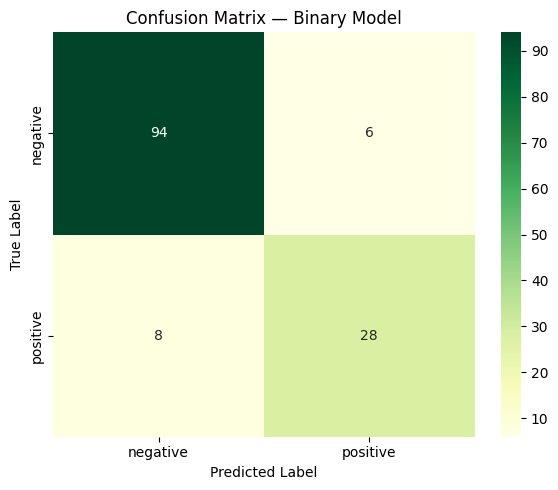

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn",
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Binary Model")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix_binary.png", dpi=150)
plt.show()